# KNN для классификации

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns  # Для более красивых графиков


In [2]:
# 1. DataFrame (используем вашу)
np.random.seed(42)
n_samples = 200
dohod = np.random.randint(30000, 100000, n_samples)
credit_his =  np.random.rand(n_samples)
veroyatno_vydacha_credita  = 0.5 * dohod + 10000 * credit_his + np.random.normal(0, 5000, n_samples)
vydacha_credita  = (veroyatno_vydacha_credita > np.mean(veroyatno_vydacha_credita)).astype(int)
data = pd.DataFrame({'доход': dohod, 'кредитная_история': credit_his, 'выдача_кредита': vydacha_credita})

In [ ]:
data

,доход,кредитная_история,выдача_кредита
0,45795,0.846661,0
1,30860,0.856324,0
2,84886,0.404508,1
3,36265,0.887770,0
4,67194,0.850928,1
...,...,...,...
195,91434,0.127690,1
196,73016,0.250016,1
197,37400,0.580544,0
198,72642,0.867117,1


In [3]:
# Подготовка данных
X = data[['доход', 'кредитная_история']]
y = data['выдача_кредита']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) #stratify=y для сохранения пропорций классов

In [4]:
# Масштабирование признаков (ОЧЕНЬ ВАЖНО для KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# KNN

In [5]:
#  KNN классификация
knn = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')  # Задаем параметры
knn.fit(X_train_scaled, y_train)


KNeighborsClassifier(metric='euclidean', weights='distance')

In [6]:
#  Оценка модели
y_pred_knn_t = knn.predict(X_train_scaled)
y_pred_knn = knn.predict(X_test_scaled)

accuracy_knn_t = accuracy_score(y_train, y_pred_knn_t)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN: Accuracy train = {accuracy_knn_t:.2f}")
print(f"KNN: Accuracy test = {accuracy_knn:.2f}")
print("\nClassification Report (KNN):\n", classification_report(y_test, y_pred_knn))

KNN: Accuracy train = 1.00
KNN: Accuracy test = 0.85

Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.85      0.85      0.85        20
           1       0.85      0.85      0.85        20

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



In [9]:
# 7. Предсказание для нового клиента
new_income = 100000
new_credit_his= 0.7

new_client = pd.DataFrame({'доход': [new_income], 'кредитная_история': [new_credit_his]})
new_client_scaled = scaler.transform(new_client)

vydacha  = knn.predict(new_client_scaled)[0]
veroyatno = knn.predict_proba(new_client_scaled)[0, 1]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_income}, Кредитная история: {new_credit_his}")
print(f"Вероятность выдачи кредита: {veroyatno:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - не выдать): {vydacha}")



Предсказание для нового клиента:
Доход: 100000, Кредитная история: 0.7
Вероятность выдачи кредита: 1.00
Решение о выдаче кредита (1 - выдать, 0 - не выдать): 1


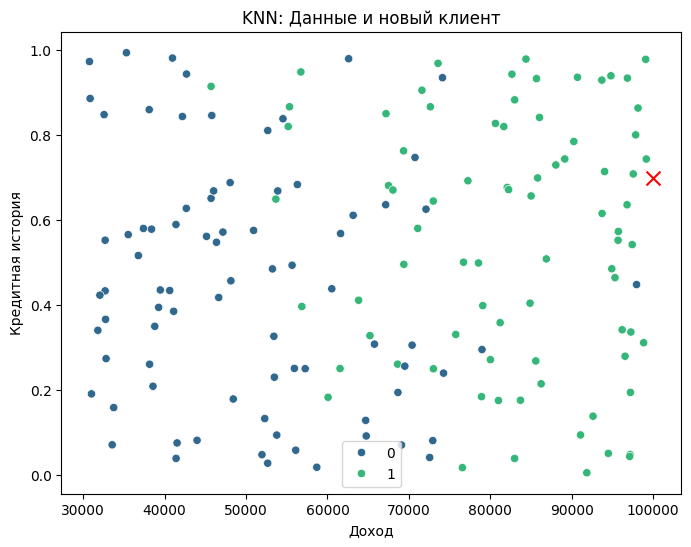

In [10]:
# 8. Визуализация (частичная, для понимания работы)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train['доход'], y=X_train['кредитная_история'], hue=y_train, palette='viridis') #Раскрашиваем по классам
plt.scatter(new_income, new_credit_his, marker='x', s=100, color='red') # Отмечаем нового клиента
plt.xlabel("Доход")
plt.ylabel("Кредитная история")
plt.title("KNN: Данные и новый клиент")
plt.legend()
plt.show()

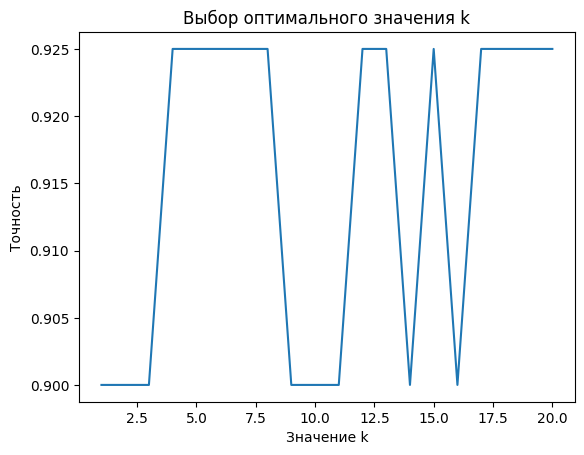

Наилучшее значение k: 4


In [11]:
# Найдем оптимальное значение k
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies)
plt.xlabel('Значение k')
plt.ylabel('Точность')
plt.title('Выбор оптимального значения k')
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"Наилучшее значение k: {best_k}")


# KNN С GridSearchCV

In [12]:
# KNN классификация
param_grid = {'n_neighbors': [3, 5, 7, 9, 11],  # Разные значения K
              'weights': ['uniform', 'distance'],  # Учитывать или нет расстояние
              'metric': ['euclidean', 'manhattan']} # Разные метрики

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy') # KNN классификатор
grid_search.fit(X_train_scaled, y_train)

# Лучшая модель
best_knn = grid_search.best_estimator_
print("Лучшие параметры для KNN:", grid_search.best_params_)


Лучшие параметры для KNN: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [13]:
#  Оценка модели
y_pred_knn_t = best_knn.predict(X_train_scaled)
y_pred_knn = best_knn.predict(X_test_scaled)

accuracy_knn_t = accuracy_score(y_train, y_pred_knn_t)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"KNN: Accuracy train = {accuracy_knn_t:.2f}")
print(f"KNN: Accuracy test = {accuracy_knn:.2f}")
print("\nClassification Report (KNN):\n", classification_report(y_test, y_pred_knn))

KNN: Accuracy train = 0.88
KNN: Accuracy test = 0.90

Classification Report (KNN):
               precision    recall  f1-score   support

           0       0.94      0.85      0.89        20
           1       0.86      0.95      0.90        20

    accuracy                           0.90        40
   macro avg       0.90      0.90      0.90        40
weighted avg       0.90      0.90      0.90        40



In [16]:
#  Предсказание для нового клиента
new_income = 60000
new_credit_his = 0.7

new_client = pd.DataFrame({'доход': [new_income], 'кредитная_история': [new_credit_his]})
new_client_scaled = scaler.transform(new_client)

loan_decision_new_client = best_knn.predict(new_client_scaled)[0]
probability_of_loan_new_client = best_knn.predict_proba(new_client_scaled)[0, 1]

print(f"\nПредсказание для нового клиента:")
print(f"Доход: {new_income}, Кредитная история: {new_credit_his}")
print(f"Вероятность выдачи кредита: {probability_of_loan_new_client:.2f}")
print(f"Решение о выдаче кредита (1 - выдать, 0 - не выдать): {loan_decision_new_client}")


Предсказание для нового клиента:
Доход: 60000, Кредитная история: 0.7
Вероятность выдачи кредита: 0.43
Решение о выдаче кредита (1 - выдать, 0 - не выдать): 0


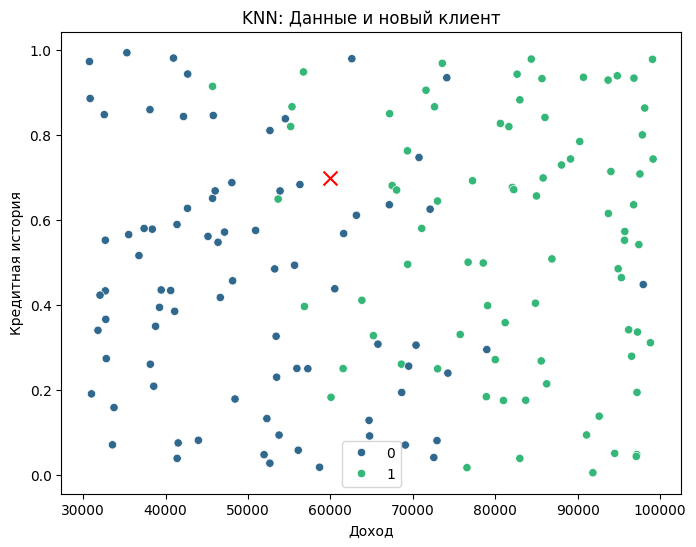

In [17]:
# Визуализация (частичная, для понимания работы)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_train['доход'], y=X_train['кредитная_история'], hue=y_train, palette='viridis') #Раскрашиваем по классам
plt.scatter(new_income, new_credit_his, marker='x', s=100, color='red') # Отмечаем нового клиента
plt.xlabel("Доход")
plt.ylabel("Кредитная история")
plt.title("KNN: Данные и новый клиент")
plt.legend()
plt.show()